# How are in demand skills trending for Data Analyst


In [ ]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


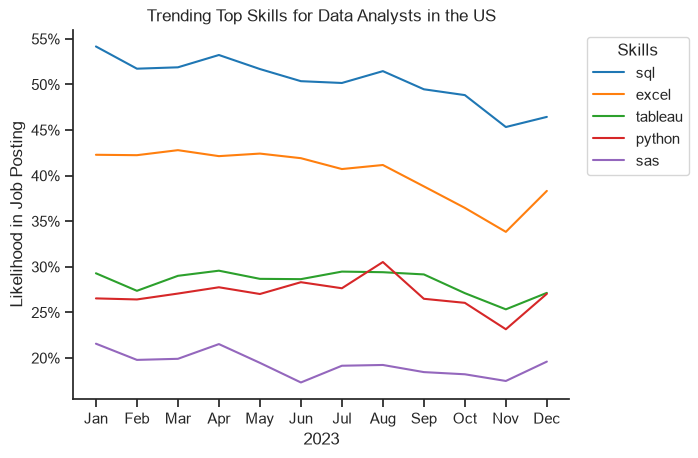

In [51]:
df_DA = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA['month_no'] = df['job_posted_date'].dt.month

exploded = df_DA.explode('job_skills')

pivot = exploded.pivot_table(index='month_no', columns='job_skills', aggfunc='size', fill_value=0)
pivot.loc['Total'] = pivot.sum()
pivot = pivot[pivot.loc['Total'].sort_values(ascending=False).index[:5]]
pivot = pivot.drop('Total')

totals = df_DA.groupby('month_no').size()

percent = pivot.div(totals / 100, axis=0)
percent = percent.reset_index()
percent['job_posted_month'] = pd.to_datetime(percent['month_no'], format='%m').dt.strftime('%b')
percent = percent.set_index('job_posted_month')
percent = percent.drop(columns='month_no')
plot = percent.iloc[:, :5]

sns.lineplot(data=plot, dashes=False, palette='tab10')
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend(title='Skills', bbox_to_anchor=(1.02, 1), loc='upper left')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))
ax.yaxis.set_major_formatter(PercentFormatter(decimals = 0))
plt.show()